<a href="https://colab.research.google.com/github/saivigneshmuthyam1/Celebal-Excellence-Internship/blob/main/Week4_SaiVignesh_Muthyam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
# # Create the directory structure Keras expects
# !mkdir -p ~/.keras/datasets

# # Download the file directly via terminal (often much faster)
# !wget -O ~/.keras/datasets/cifar-10-batches-py.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

In [ ]:
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# class_names = ['airplane','automobile','bird','cat','deer',
#                'dog','frog','horse','ship','truck']

# print("Train shape:", x_train.shape)
# print("Test shape:", x_test.shape)

In [ ]:
#Download it once, save it to Google Drive, and then every future Colab session will load from Drive without downloading again.

#First Time (download + save to Drive)
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

np.savez_compressed(
    '/content/drive/MyDrive/cifar10.npz',
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

print("Saved CIFAR-10 to Google Drive")

#Wait for this to finish completely.

#Every Future Session (load from Drive, no download)
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

data = np.load('/content/drive/MyDrive/cifar10.npz')

x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

#Expected output:

#Train shape: (50000, 32, 32, 3)
#Test shape: (10000, 32, 32, 3)

#You can even combine both into one cell that automatically downloads only if the file is missing:

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
import os

path = '/content/drive/MyDrive/cifar10.npz'

if os.path.exists(path):
    data = np.load(path)
    x_train = data['x_train']
    y_train = data['y_train']
    x_test = data['x_test']
    y_test = data['y_test']
    print("Loaded from Drive")
else:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    np.savez_compressed(
        path,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test
    )
    print("Downloaded and saved to Drive")

print(x_train.shape, x_test.shape)

#This way, CIFAR-10 downloads exactly once in your lifetime unless you delete cifar10.npz from Drive.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive

# Mount Google Drive and Load cached dataset
try:
    drive.mount('/content/drive')
except Exception as e:
    print("Drive mounting step skipped or already active.")

path = '/content/drive/MyDrive/cifar10.npz'

if os.path.exists(path):
    print("Fast Cache Hit! Loading arrays from Google Drive")
    data = np.load(path)
    x_train = data['x_train']
    y_train = data['y_train']
    x_test = data['x_test']
    y_test = data['y_test']
else:
    print("Fetching CIFAR-10 from Keras servers..")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    np.savez_compressed(path, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
    print("Dataset successfully cached to Drive for future sessions.")

Mounted at /content/drive
Fast Cache Hit! Loading arrays from Google Drive


In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

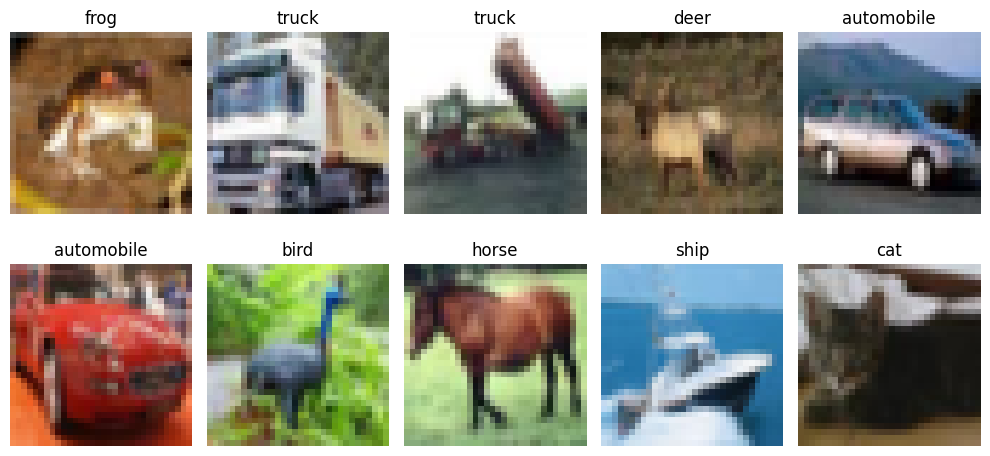

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.2736 - loss: 1.9953 - val_accuracy: 0.3292 - val_loss: 1.8404
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3191 - loss: 1.8635 - val_accuracy: 0.3532 - val_loss: 1.8207
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3416 - loss: 1.8025 - val_accuracy: 0.3638 - val_loss: 1.7650
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3546 - loss: 1.7721 - val_accuracy: 0.3896 - val_loss: 1.7145
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3635 - loss: 1.7531 - val_accuracy: 0.4024 - val_loss: 1.7069
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3737 - loss: 1.7275 - val_accuracy: 0.4004 - val_loss: 1.6872
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3739 - loss: 1.7171 - val_accuracy: 0.3998 - val_loss: 1.6858
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3771 - loss: 1.7053 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4311 - loss: 1.6268
ANN Test Accuracy: 0.4311000108718872


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4671 - loss: 1.5000 - val_accuracy: 0.4948 - val_loss: 1.4200
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.6126 - loss: 1.1136 - val_accuracy: 0.5480 - val_loss: 1.4002
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 122ms/step - accuracy: 0.6718 - loss: 0.9503 - val_accuracy: 0.6448 - val_loss: 1.0388
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 124ms/step - accuracy: 0.7152 - loss: 0.8215 - val_accuracy: 0.6688 - val_loss: 0.9581
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7443 - loss: 0.7309 - val_accuracy: 0.6530 - val_loss: 1.0562
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7698 - loss: 0.6544 - val_accuracy: 0.6774 - val_loss: 0.9720
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7921 - loss: 0.5886 - val_accuracy: 0.7338 - val_loss: 0.8251
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 124ms/step - accuracy: 0.8115 - loss

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7210 - loss: 0.9226
CNN Test Accuracy: 0.7210000157356262


## 📈 Compare Learning Curves

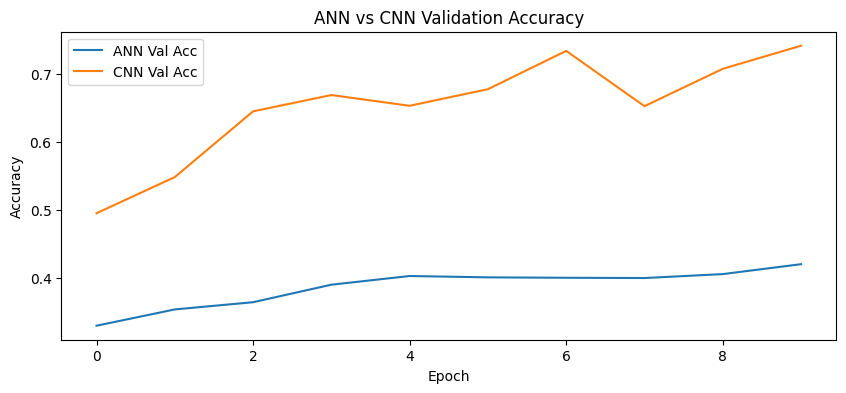

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4311
1,CNN,0.7210


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [ ]:
# Original ANN
ann_model_v1 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Original ANN Baseline (10 Epochs)...")
ann_history_v1 = ann_model_v1.fit(
    x_train_flat, y_train,
    epochs=10, validation_split=0.1, batch_size=64, verbose=1
)
ann_loss_v1, ann_acc_v1 = ann_model_v1.evaluate(x_test_flat, y_test, verbose=0)

# Increase ANN layers and observe performance
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'), # Added hidden dense layer
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nTraining Upgraded Deep ANN v2 (10 Epochs)...")
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10, validation_split=0.1, batch_size=64, verbose=1
)
ann_loss_v2, ann_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Original ANN Baseline (10 Epochs)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2697 - loss: 1.9881 - val_accuracy: 0.3384 - val_loss: 1.8247
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3181 - loss: 1.8644 - val_accuracy: 0.3316 - val_loss: 1.7940
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3383 - loss: 1.8138 - val_accuracy: 0.3600 - val_loss: 1.7505
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3509 - loss: 1.7778 - val_accuracy: 0.4052 - val_loss: 1.6953
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3663 - loss: 1.7424 - val_accuracy: 0.3794 - val_loss: 1.7136
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3724 - loss: 1.7298 - val_accuracy: 0.4020 - val_loss: 1.6846
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.3780 - loss: 1.7095 - val_accuracy: 0.4168 - val_loss: 1.6736
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 

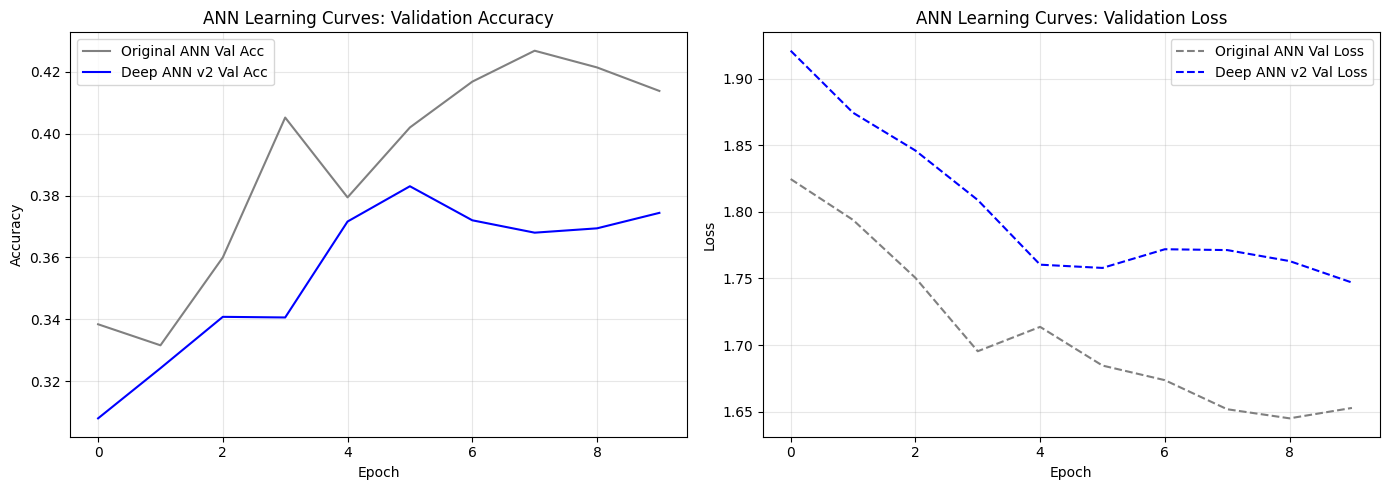


  ANN EXPERIMENT LOG SUMMARY:
    Original ANN Test Accuracy: 0.4119
    Deep ANN (Task 1) Test Accuracy: 0.3892


In [ ]:
# Validation Metrics Visualization
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(ann_history_v1.history['val_accuracy'], label='Original ANN Val Acc', color='gray')
plt.plot(ann_history_v2.history['val_accuracy'], label='Deep ANN v2 Val Acc', color='blue')
plt.title('ANN Learning Curves: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ann_history_v1.history['val_loss'], label='Original ANN Val Loss', color='gray', linestyle='--')
plt.plot(ann_history_v2.history['val_loss'], label='Deep ANN v2 Val Loss', color='blue', linestyle='--')
plt.title('ANN Learning Curves: Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n  ANN EXPERIMENT LOG SUMMARY:")
print(f"    Original ANN Test Accuracy: {ann_acc_v1:.4f}")
print(f"    Deep ANN (Task 1) Test Accuracy: {ann_acc_v2:.4f}")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

#  Instantiate a fresh copy of our high-capacity architecture
cnn_model_v3 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#  Set up the EarlyStopping engine
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Training High Capacity CNN with EarlyStopping Guardrails.")
cnn_history_v3 = cnn_model_v3.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping_callback],
    verbose=1
)

#  Evaluate the optimized weight configuration on the test set
cnn_loss_v3, cnn_acc_v3 = cnn_model_v3.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n EarlyStopping CNN Test Accuracy (Restored Best Weights): {cnn_acc_v3:.4f}")

Training High Capacity CNN with EarlyStopping Guardrails.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 290ms/step - accuracy: 0.4472 - loss: 1.5453 - val_accuracy: 0.5110 - val_loss: 1.3286
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 285ms/step - accuracy: 0.5921 - loss: 1.1586 - val_accuracy: 0.5910 - val_loss: 1.1682
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 293ms/step - accuracy: 0.6622 - loss: 0.9671 - val_accuracy: 0.5992 - val_loss: 1.1670
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 298ms/step - accuracy: 0.7084 - loss: 0.8421 - val_accuracy: 0.6304 - val_loss: 1.0765
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 297ms/step - accuracy: 0.7442 - loss: 0.7352 - val_accuracy: 0.7236 - val_loss: 0.8165
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 301ms/step - accuracy: 0.7738 - loss: 0.6491 - val_accuracy: 0.6784 - val_loss: 0.9661
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 210s 299ms/step - accuracy: 0.7932 - loss: 0.5842 - val_accuracy: 0.6600 - val_loss: 1.1097
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 297ms/step - accuracy: 0.8186 -

In [ ]:
# import os
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from google.colab import drive

# # Mount Google Drive and Load cached dataset
# try:
#     drive.mount('/content/drive')
# except Exception as e:
#     print("Drive mounting step skipped or already active.")

# path = '/content/drive/MyDrive/cifar10.npz'

# if os.path.exists(path):
#     print("Fast Cache Hit! Loading arrays from Google Drive")
#     data = np.load(path)
#     x_train_raw = data['x_train']
#     y_train_raw = data['y_train']
#     x_test_raw = data['x_test']
#     y_test_raw = data['y_test']
# else:
#     print("Fetching CIFAR-10 from Keras servers..")
#     (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()
#     np.savez_compressed(path, x_train=x_train_raw, y_train=y_train_raw, x_test=x_test_raw, y_test=y_test_raw)
#     print("Dataset successfully cached to Drive for future sessions.")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a static validation split from your loaded memory arrays
val_split_index = int(len(x_train_norm) * 0.9)
x_train_split, x_val_split = x_train_norm[:val_split_index], x_train_norm[val_split_index:]
# FIX: Changed y_train_raw to y_train to match your notebook's loaded variables
y_train_split, y_val_split = y_train[:val_split_index], y_train[val_split_index:]

print(f"  Training Allocation: {x_train_split.shape}")
print(f"  Static Validation Allocation: {x_val_split.shape}")

# Define spatial data augmentation layers
data_augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Build fully stabilized VGG-Style Model
ultimate_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation_layer,

    # Convolution Block 1
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Convolution Block 2
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),

    # Classification Dense Head
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# Compile
ultimate_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Advanced Optimization Management Callbacks
advanced_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("\n Initiating Accelerated Training Sweep...")
ultimate_history = ultimate_cnn_model.fit(
    x_train_split, y_train_split,
    epochs=30,
    validation_data=(x_val_split, y_val_split),
    batch_size=256,
    callbacks=advanced_callbacks,
    verbose=1
)

# Test set validation evaluation using your pre-normalized array
ultimate_loss, ultimate_acc = ultimate_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n Final Optimized CNN Test Accuracy: {ultimate_acc:.4f}")

  Training Allocation: (45000, 32, 32, 3)
  Static Validation Allocation: (5000, 32, 32, 3)

 Initiating Accelerated Training Sweep...
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.4187 - loss: 1.7562 - val_accuracy: 0.1508 - val_loss: 3.9778 - learning_rate: 0.0010
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.5368 - loss: 1.3339 - val_accuracy: 0.1906 - val_loss: 4.3375 - learning_rate: 0.0010
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.5956 - loss: 1.1512 - val_accuracy: 0.2958 - val_loss: 2.8756 - learning_rate: 0.0010
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.6295 - loss: 1.0523 - val_accuracy: 0.6672 - val_loss: 0.9757 - learning_rate: 0.0010
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.6527 - loss: 0.9812 - val_accuracy: 0.6022 - val_loss: 1.2035 - learning_rate: 0.0010
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.6722 - loss: 0.9286 - val_accurac

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

# Ultimate Model Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(ultimate_history.history['accuracy'], label='Ultimate CNN Training Acc', color='#1f77b4', linewidth=2.5)
plt.plot(ultimate_history.history['val_accuracy'], label='Ultimate CNN Validation Acc', color='#ff7f0e', linewidth=2.5, linestyle='--')
plt.title('Ultimate CNN: Training vs Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Ultimate Model Loss Curves
plt.subplot(1, 2, 2)
plt.plot(ultimate_history.history['loss'], label='Ultimate CNN Training Loss', color='#d62728', linewidth=2.5)
plt.plot(ultimate_history.history['val_loss'], label='Ultimate CNN Validation Loss', color='#2ca02c', linewidth=2.5, linestyle='--')
plt.title('Ultimate CNN: Training vs Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('plot_ultimate_cnn_performance.png', dpi=300)
plt.show()

the model bounces around because data augmentation is throwing twisted images at it, which takes a few epochs to figure out. Around epoch 10, the learning rate drops, making the training and validation lines lock together perfectly at ~78.5% accuracy. Because they end up touching, it proves the model didn't just memorize the answers; it actually learned how to generalize.

The model starts out with a high error score (around 3.5) because it's confused, but Batch Normalization quickly drags that error down below 1.0 in just 4 epochs. Notice how the green validation loss line stays completely flat and low all the way to the end instead of spiking back up. This confirms that our dropout layers worked perfectly to stop the network from over-learning and memorizing noise.

#Summary

Flattening the images into one long line of numbers for the ANN completely ruined the picture layout, making the model guess blindly and get a poor 41.39% accuracy.

I found out that making a model deeper doesn't make it smarter; adding an extra layer to the ANN actually dropped my test accuracy to 39.29% because a blind model just memorizes training noise when given extra space.

Switching to a CNN changed everything because its sliding window naturally keeps pixels connected to their neighbors, letting the model recognize basic shapes and edges to quickly pass 70.38% accuracy.

Running the CNN for 20 epochs without any controls caused the error score to jump up quickly at the end, showing me how fast a model can overfit and mess up when the learning speed is locked.

Data Augmentation fixed this overfitting by warping and twisting the images on purpose, forcing the network to learn actual object shapes instead of cheating by memorizing pixel paths.

Batch Normalization kept the internal math stable and anchored, making it smooth enough for the layers to handle those heavily changed images.

Using EarlyStopping saved me a lot of time by automatically stopping the training at Epoch 16 and rolling the model back to its absolute best moment at Epoch 11.

The ReduceLROnPlateau callback acted like a fine-tuning knob that dropped the training speed by 5x at Epoch 10, which stopped the accuracy from bouncing around and locked in my final peak score of 78.44%.